In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
#let's start by loading the kamis maize prices dataset to understand the price trends and patterns in the market
kamis_df = pd.read_csv('kamis_maize_prices.csv')
print(kamis_df.info())
print(kamis_df.head())

<class 'pandas.DataFrame'>
RangeIndex: 21888 entries, 0 to 21887
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Commodity_Classification  21888 non-null  str    
 1   Commodity                 21888 non-null  str    
 2   Classification            21888 non-null  str    
 3   County                    21888 non-null  str    
 4   Market                    21888 non-null  str    
 5   Date                      21888 non-null  str    
 6   Year                      21888 non-null  int64  
 7   Month                     21888 non-null  int64  
 8   Year_Month                21888 non-null  str    
 9   WeekofYear                21888 non-null  int64  
 10  Year_Week                 21888 non-null  str    
 11  SupplyVolume              17382 non-null  float64
 12  Retail                    21016 non-null  float64
 13  Wholesale                 20203 non-null  float64
 14  Unit             

In [ ]:

kamis_df["Date"] = pd.to_datetime(kamis_df["Date"])

print(f"Min Date: {kamis_df['Date'].min()}, Max Date: {kamis_df['Date'].max()}")

print(f"Number of Unique Counties: {kamis_df['County'].nunique()}")
print(f"Commodity Counts:\n{kamis_df['Commodity'].value_counts()}") #so the commodities present are dry maize

print(f"Commodity Classification Counts:\n{kamis_df['Commodity_Classification'].value_counts()}")
#we have 3 classifications: dry white, dry yellow and dry mixed traditional maize but since agribora only has prices of white maize,\n
# we will focus on dry white maize to ensure consistency between the datasets

kamis_df = kamis_df[kamis_df["Commodity_Classification"] == "Dry_White_Maize"]
#check for missing values
print(f"Missing values:\n{kamis_df.isna().sum()}")

Min Date: 2021-05-24 00:00:00, Max Date: 2025-07-31 00:00:00
Number of Unique Counties: 47
Commodity Counts:
Commodity
Dry_Maize    21888
Name: count, dtype: int64
Commodity Classification Counts:
Commodity_Classification
Dry_White_Maize                14751
Dry_Maize_Mixed_Traditional     5168
Dry_Yellow_Maize                1969
Name: count, dtype: int64
Missing values:
Commodity_Classification       0
Commodity                      0
Classification                 0
County                         0
Market                         0
Date                           0
Year                           0
Month                          0
Year_Month                     0
WeekofYear                     0
Year_Week                      0
SupplyVolume                2801
Retail                       538
Wholesale                    886
Unit                           0
dtype: int64


In [ ]:
#next we'll investigate columns with missing values and decide how to handle them
print(kamis_df["SupplyVolume"].describe())
#mean is 12,721 while median is 5000 so mean is higher than median
# which suggests that there are some high values in the supply volume column that are skewing the distribution to the right. (max is 4.7million!)

#let's use log transformation to reduce the skewness of the supply volume data and make it more normally distributed
kamis_df["SupplyVolume"] = kamis_df.groupby("County")["SupplyVolume"].transform(lambda x: x.fillna(x.median()))
kamis_df["Log_SupplyVolume"] = np.log(kamis_df["SupplyVolume"] + 1) # Adding 1 to avoid log(0) issues
print(kamis_df["Log_SupplyVolume"].describe())

count    1.195000e+04
mean     1.272194e+04
std      6.003695e+04
min      0.000000e+00
25%      2.000000e+03
50%      5.000000e+03
75%      1.200000e+04
max      4.730000e+06
Name: SupplyVolume, dtype: float64
count    14751.000000
mean         8.346058
std          1.633879
min          0.000000
25%          7.741099
50%          8.412055
75%          9.210440
max         15.369436
Name: Log_SupplyVolume, dtype: float64


In [ ]:
#before we look at retail and wholesale, let's see the spread 
kamis_df["Spread"] = kamis_df["Retail"] - kamis_df["Wholesale"]
print(kamis_df["Spread"].describe())

print(f"Counties with Highest Average Spread:\n{kamis_df.groupby("County")["Spread"].mean().sort_values(ascending=False).head(5)}")

print(f"Counties with Lowest Average Spread:\n{kamis_df.groupby("County")["Spread"].mean().sort_values(ascending=False).tail(5)}")


#we also see negative spreads -> will look into this once we clean up retail and wholesale prices
#from the mean, max and min values, we can see there my be some outliers in retail and wholesale prices

#spreads are highest in Lamu,Turkana, Kilifi, Mandera, Isiolo- could be due to transportation costs and low production
# spreads are lowest in Migori, Nyandarua, Makueni, Nakuru perhaps due to higher local production and better road infrastructure

count    13332.000000
mean        11.400386
std         48.487324
min        -75.000000
25%          5.000000
50%          9.440000
75%         15.000000
max       5444.440000
Name: Spread, dtype: float64
Counties with Highest Average Spread:
County
Lamu       30.000000
Turkana    27.916916
Kilifi     26.017647
Mandera    19.660274
Isiolo     19.420000
Name: Spread, dtype: float64
Counties with Lowest Average Spread:
County
Kakamega     6.114406
Nakuru       6.093056
Makueni      5.516761
Nyandarua    5.074078
Migori       4.899134
Name: Spread, dtype: float64


count    13865.000000
mean        49.850423
std         17.733259
min          0.020000
25%         34.440000
50%         50.000000
75%         64.000000
max        450.000000
Name: Wholesale, dtype: float64


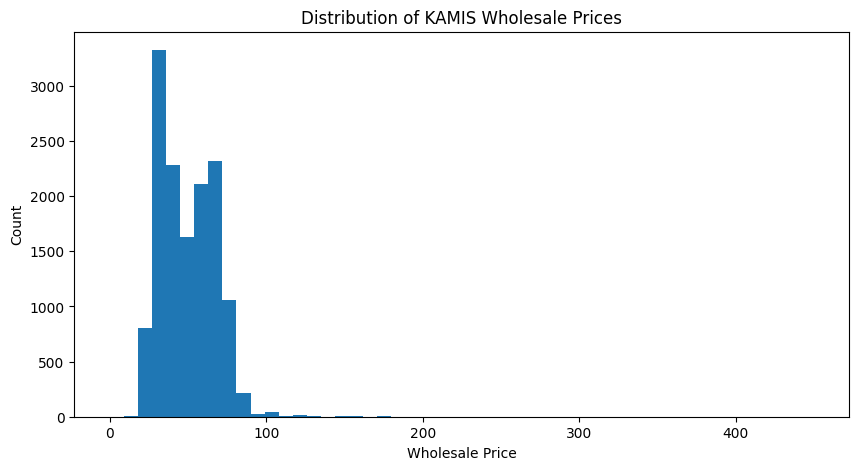

In [ ]:
#let's deal with retail and wholesale price columns separately
print(kamis_df["Wholesale"].describe())
#wholesale prices look reasonable with the exception of the max value of 450 which is much higher than the mean and median

#let's check the distribution of wholesale prices to see if there are any outliers that might be skewing the data
plt.figure(figsize=(10, 5))
plt.hist(kamis_df["Wholesale"].dropna(), bins=50)
plt.xlabel("Wholesale Price")
plt.ylabel("Count")
plt.title("Distribution of KAMIS Wholesale Prices")
plt.show()


Records with Wholesale Price > 100:
            County                       Market       Date  Wholesale  Retail  \
8519   Trans-Nzoia               Sibanga_Market 2022-06-24      450.0   450.0   
8742       Turkana  Lodwar_Fresh_Produce_Market 2022-07-05      200.0   200.0   
15457  Trans-Nzoia   Kitale_Municipality_Market 2023-05-22      180.0   190.0   
8437         Kisii              Nyakongo_Market 2022-06-19      180.0   190.0   
17908       Nakuru                Bahati_Market 2023-10-24      180.0   180.0   
...            ...                          ...        ...        ...     ...   
15262      Muranga        Kabati_Muranga_Market 2023-05-13      100.0   110.0   
15696      Kericho          Kericho_Town_Market 2023-06-03      100.0   110.0   
15815        Busia         Port_Victoria_Market 2023-06-09      100.0   110.0   
15886      Nyamira              Kebirigo_Market 2023-06-13      100.0   110.0   
21809     Kakamega              Kipkaren_Market 2025-07-24      100.0   1

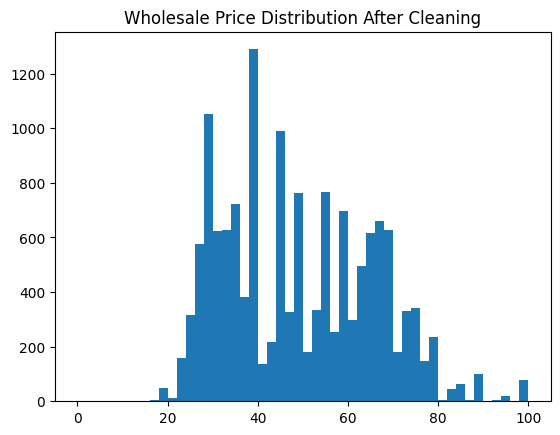

In [ ]:
#let's filter out wholesale prices that are above 100 as they seem to be outliers and could skew our analysis
print(f"Records with Wholesale Price > 100:\n{kamis_df.loc[kamis_df["Wholesale"] >= 100,["County", "Market", "Date", "Wholesale", "Retail", "SupplyVolume", "Unit"]
].sort_values("Wholesale", ascending=False)}")

#notice those with highest wholesale prices have almost the same retail price which is unusual and suggests that prices might be a data entry error 
#since number of records with wholesale price > 100 is small, let's clip their wholesale price to 100 to reduce their impact on our analysis
kamis_df["Wholesale"] = kamis_df["Wholesale"].clip(upper=100)

#fill the missing values with median wholesale price for each county to ensure that we have complete data for our analysis
kamis_df["Wholesale"] = kamis_df.groupby("County")["Wholesale"].transform(lambda x: x.fillna(x.median()))

#confirm that the distribution of wholesale prices looks better after clipping the outliers and filling the missing values
plt.hist(kamis_df["Wholesale"], bins=50)
plt.title("Wholesale Price Distribution After Cleaning")
plt.show()



count    14213.000000
mean        60.586427
std         50.859203
min          6.390000
25%         40.000000
50%         60.000000
75%         75.000000
max       5500.000000
Name: Retail, dtype: float64


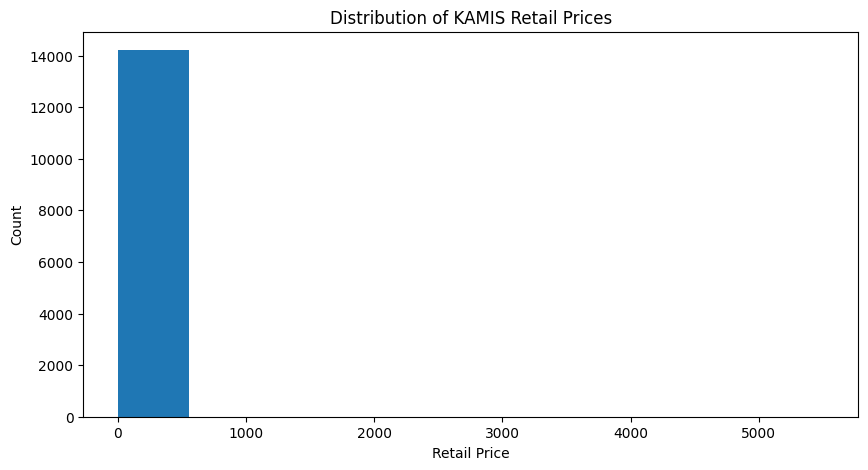

In [8]:
#let's do the same for retail prices
print(kamis_df['Retail'].describe())

plt.figure(figsize=(10, 5))
plt.hist(kamis_df["Retail"].dropna(), bins=10)
plt.xlabel("Retail Price")
plt.ylabel("Count")
plt.title("Distribution of KAMIS Retail Prices")
plt.show()


In [ ]:
print(f"Retail prices > 180:\n{kamis_df.loc[kamis_df["Retail"] >= 180,["County", "Market", "Date", "Wholesale", "Retail", "SupplyVolume", "Unit"]].sort_values("Retail", ascending=False)}" )
#high retail prices are frequently occuring in Kwale and Turkana which are arid counties with low supply volumes so it is possible that these high retail prices \n
# are due to scarcity of maize in these regions. However, since the number of records with retail price > 180 is small, let's clip them to 180 to \n
# reduce their impact on our analysis.
print(f"Number of records with retail price > 180: {(kamis_df['Retail'] > 180).sum()}")


#you can see that these are outliers so let's clip retail prices at 180 to reduce their impact on our analysis
kamis_df["Retail"] = kamis_df["Retail"].clip(upper=180)

#fill missing retail prices with median retail price for each county to ensure that we have complete data for our analysis
kamis_df["Retail"] = kamis_df.groupby("County")["Retail"].transform(lambda x: x.fillna(x.median())) 

Retail prices > 180:
            County                         Market       Date  Wholesale  \
21286        Nandi  Chepterit_Market_Nandi_Market 2025-05-28      55.56   
8519   Trans-Nzoia                 Sibanga_Market 2022-06-24     100.00   
14268      Mandera                   Elwak_Market 2023-03-20      64.00   
17086      Turkana                Lokichar_Market 2023-08-20     100.00   
15007      Turkana                Lokichar_Market 2023-04-29      50.00   
16496      Baringo                Nginyang_Market 2023-07-17      77.78   
8742       Turkana    Lodwar_Fresh_Produce_Market 2022-07-05     100.00   
19101        Nandi                 Kabiyet_Market 2024-03-12     100.00   
16306      Turkana                Lokichar_Market 2023-07-05      60.00   
16076      Bungoma            Bungoma_Town_Market 2023-06-23      85.00   
13928      Turkana                Lokichar_Market 2023-03-02      50.00   
14073      Turkana                Lokichar_Market 2023-03-09      50.00   
1424

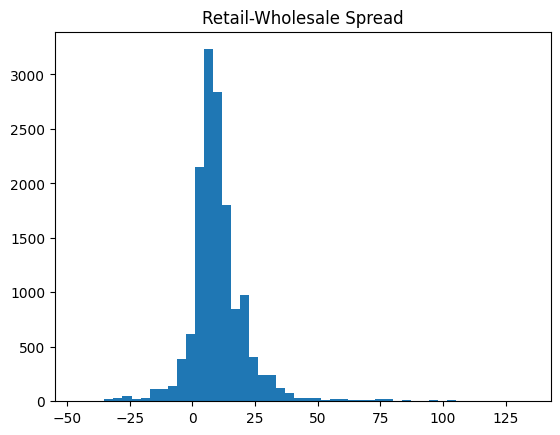

Group counties by spread:
County
Lamu            30.000000
Kilifi          27.929412
Turkana         27.169252
Isiolo          19.420000
Mandera         19.194521
Garissa         17.459677
Tana-River      17.222500
Embu            16.702865
Taita-Taveta    15.174947
Nairobi         15.050697
Name: Spread, dtype: float64


In [ ]:
#let's recalculate the spread after cleaning the retail and wholesale price columns
kamis_df["Spread"] = kamis_df["Retail"] - kamis_df["Wholesale"]
kamis_df["Spread"].describe()

plt.hist(kamis_df["Spread"], bins=50)
plt.title("Retail-Wholesale Spread")
plt.show()

print(f"Group counties by spread:\n{kamis_df.groupby("County")["Spread"].mean().sort_values(ascending=False).head(10)}")
#Again, Lamu, Kilifi, Turkana, Isiolo, Mandera have the highest spreads

In [ ]:
#let's go back and check the records where spread is negative and see how many of them there are
print(f"Records with negative spread:\n{kamis_df.loc[kamis_df["Spread"] < 0, ["County","Market","Date","Wholesale","Retail","Spread"]].head(3).sort_values("Spread")}")

#interesting that they mostly occur on the same day- could be a data entry error(2021-05-24)
print(f"Dates with negative spread:\n{kamis_df.loc[kamis_df["Spread"] < 0, "Date"].value_counts().head(3)}")

#I will remove records on 2021-05-24 as they are likely to be errors and could skew our analysis
# Records on other dates could be due to economic conditions like loss, discounts, etc so we can keep them as they aren't too extreme and occur on the same day
kamis_df = kamis_df[kamis_df["Date"] != "2021-05-24"]


Records with negative spread:
              County           Market       Date  Wholesale  Retail  Spread
51           Baringo  Kabarnet_Market 2021-05-24      50.00    30.0  -20.00
103  Elgeyo-Marakwet      Flax_Market 2021-05-24      31.11    28.0   -3.11
58           Bungoma    Chwele_Market 2021-05-24      24.44    24.0   -0.44
Dates with negative spread:
Date
2021-05-24    59
2022-08-08     7
2021-06-17     5
Name: count, dtype: int64


In [ ]:
#cleaned data looks good now, let's do some weekly aggregation to see the trends in wholesale and retail prices by countyover time
kamis_weekly = (
    kamis_df
    .groupby(["County", "Year_Week"])
    .agg({
        "Wholesale": "median",
        "Retail": "median",
        "Spread": "median",
        "Log_SupplyVolume": "median"
    })
    .reset_index()
)


In [14]:
#let's now check our primary dataset - the agribora dataset 
agribora_df = pd.read_csv('agribora_maize_prices.csv')
print(agribora_df.info())
print(agribora_df.head())
agribora_df["Date"] = pd.to_datetime(agribora_df["Date"])

<class 'pandas.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   County                    239 non-null    str    
 1   Date                      239 non-null    str    
 2   WholeSale                 239 non-null    float64
 3   Commodity_Classification  239 non-null    str    
 4   Year_Week                 239 non-null    str    
 5   WeekofYear                239 non-null    int64  
dtypes: float64(1), int64(1), str(4)
memory usage: 11.3 KB
None
        County        Date  WholeSale Commodity_Classification Year_Week  \
0    Kirinyaga  2023-10-02     48.890          Dry_White_Maize   2023-40   
1      Nairobi  2023-10-02     49.630          Dry_White_Maize   2023-40   
2  Uasin-Gishu  2023-10-02     46.670          Dry_White_Maize   2023-40   
3       Kisumu  2023-10-02     43.885          Dry_White_Maize   2023-40   
4       Kiambu  2023-10

In [15]:
agribora_df_46_51 = pd.read_csv('agribora_maize_prices_weeks_46_to_51.csv')
print(agribora_df_46_51.info())
print(agribora_df_46_51.head())

agribora_df_46_51["Date"] = pd.to_datetime(agribora_df_46_51["Date"])

#let's join the two agribora datasets to get a complete picture of maize prices from week 1 to week 51
agribora_df = pd.concat([agribora_df, agribora_df_46_51], ignore_index=True)
print(agribora_df.info())
print(agribora_df.head())

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   County                    30 non-null     str    
 1   Date                      30 non-null     str    
 2   WholeSale                 30 non-null     float64
 3   Commodity_Classification  30 non-null     str    
 4   Year_Week                 30 non-null     str    
 5   WeekofYear                30 non-null     int64  
dtypes: float64(1), int64(1), str(4)
memory usage: 1.5 KB
None
        County        Date  WholeSale Commodity_Classification Year_Week  \
0       Kiambu  2025-11-10  38.333333          Dry_White_Maize   2025-46   
1    Kirinyaga  2025-11-10  38.888889          Dry_White_Maize   2025-46   
2      Mombasa  2025-11-10  36.111111          Dry_White_Maize   2025-46   
3      Nairobi  2025-11-10  36.800000          Dry_White_Maize   2025-46   
4  Uasin-Gishu  2025-11-10

In [16]:
agribora_df = agribora_df.rename(columns={"WholeSale": "agribora_wholesale"})

print(f"Minimum date in agribora_df: {agribora_df['Date'].min()}")
print(f"Maximum date in agribora_df: {agribora_df['Date'].max()}")

print(f"Missing values in agribora_df:\n{agribora_df.isna().sum()}")

Minimum date in agribora_df: 2023-10-02 00:00:00
Maximum date in agribora_df: 2025-12-15 00:00:00
Missing values in agribora_df:
County                      0
Date                        0
agribora_wholesale          0
Commodity_Classification    0
Year_Week                   0
WeekofYear                  0
dtype: int64


In [ ]:
print(agribora_df.groupby("County")["Year_Week"].count().sort_values())
#only 16 counties are present in this dataset so we will only use those ones- we'll later just use our 3 main counties of interest
#some counties are missing certain weeks so let's forward fill the missing weeks with the last available price 
# to ensure that we have a complete time series for each county
# We're assuming that the wholesale price remains constant during the missing weeks 

all_agri_data = []

for county in agribora_df["County"].unique():
    
    county_df = agribora_df[agribora_df["County"] == county].sort_values("Date")
    
    full_weeks = pd.date_range(
        start=county_df["Date"].min(),
        end=county_df["Date"].max(),
        freq="W-MON"
    )
    
    full_df = pd.DataFrame({"Date": full_weeks})
    full_df["County"] = county
    
    merged = full_df.merge(county_df, on=["County","Date"], how="left")
    
    all_agri_data.append(merged)

agribora_panel = pd.concat(all_agri_data)

#only 6 counties have some reasonalbly complete data

County
Busia           1
Kakamega        1
Machakos        1
Meru            1
Nyeri           2
Trans-Nzoia     2
Embu            3
Kajiado         3
Nakuru          3
Bungoma         5
Kisumu         15
Mombasa        23
Kirinyaga      31
Kiambu         36
Nairobi        62
Uasin-Gishu    80
Name: Year_Week, dtype: int64


In [18]:
#forward fill the missing wholesale prices for each county
agribora_panel["agribora_wholesale"] = (
    agribora_panel
    .groupby("County")["agribora_wholesale"]
    .ffill()
)

agribora_panel["Commodity_Classification"] = "Dry_White_Maize"

agribora_panel["Year"] = agribora_panel["Date"].dt.isocalendar().year
agribora_panel["Week"] = agribora_panel["Date"].dt.isocalendar().week
agribora_panel["Year_Week"] = agribora_panel["Year"].astype(str) + "-" + agribora_panel["Week"].astype(str).str.zfill(2)

#drop these columns as we won't need them for our analysis and to avoid redundancy with the Year_Week column
agribora_panel = agribora_panel.drop(columns=["Year", "Week","WeekofYear"], errors="ignore")

print(agribora_panel.shape)

(696, 5)


In [19]:
#we're only interested in these 3 counties so let's restrict our analysis to them
target_counties = [
    "Kirinyaga",
    "Nairobi",
    "Uasin-Gishu"
]

agribora_panel = agribora_panel[agribora_panel["County"].isin(target_counties)]


In [20]:
#let's create multiple lag features, rolling mean and standard deviation to capture short term patterns and volatility in preparation for forecasting future prices
agribora_panel = agribora_panel.sort_values(["County","Date"])

agribora_panel["lag_1"] = (agribora_panel.groupby("County")["agribora_wholesale"].shift(1))

agribora_panel["lag_2"] = (agribora_panel.groupby("County")["agribora_wholesale"].shift(2))

agribora_panel["lag_4"] = (agribora_panel.groupby("County")["agribora_wholesale"].shift(4))

agribora_panel["rolling_mean_4"] = (
    agribora_panel.groupby("County")["agribora_wholesale"]
    .rolling(4)
    .mean()
    .reset_index(level=0, drop=True)
)

agribora_panel["rolling_std_4"] = (
    agribora_panel.groupby("County")["agribora_wholesale"]
    .rolling(4)
    .std()
    .reset_index(level=0, drop=True)
)

agribora_panel.tail(5)

,Date,County,agribora_wholesale,Commodity_Classification,Year_Week,lag_1,lag_2,lag_4,rolling_mean_4,rolling_std_4
111,2025-11-17,Uasin-Gishu,32.777143,Dry_White_Maize,2025-47,33.222222,38.335000,38.335000,35.667341,3.085701
112,2025-11-24,Uasin-Gishu,32.554000,Dry_White_Maize,2025-48,32.777143,33.222222,38.335000,34.222091,2.755973
113,2025-12-01,Uasin-Gishu,33.334000,Dry_White_Maize,2025-49,32.554000,32.777143,38.335000,32.971841,0.368035
114,2025-12-08,Uasin-Gishu,34.888889,Dry_White_Maize,2025-50,33.334000,32.554000,33.222222,33.388508,1.052661
115,2025-12-15,Uasin-Gishu,41.666667,Dry_White_Maize,2025-51,34.888889,33.334000,32.777143,35.610889,4.152209


County
Kirinyaga      Axes(0.125,0.11;0.775x0.77)
Nairobi        Axes(0.125,0.11;0.775x0.77)
Uasin-Gishu    Axes(0.125,0.11;0.775x0.77)
Name: agribora_wholesale, dtype: object

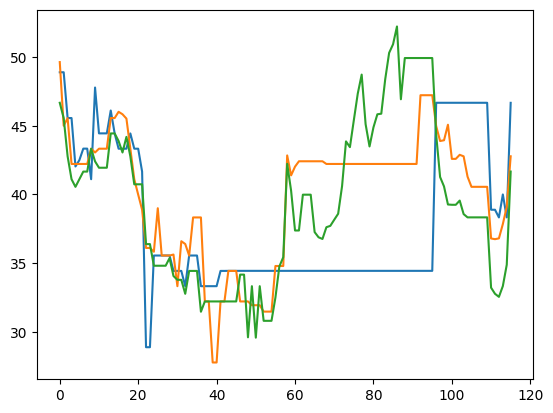

In [ ]:
agribora_panel.groupby("County")["agribora_wholesale"].plot()
#we notice several counties prices drop and rise around the same time which could be due to seasonality in maize prices or market dynamics.
#prices revert after dropping(mean reversion) which is a common phenomenon in commodity prices


In [ ]:
agribora_panel = agribora_panel.sort_values(["County","Date"])

#since we're predicting price 1 and 2 weeks from the last available week in the dataset, we need to create target variables for those weeks
agribora_panel["target_t1"] = (agribora_panel.groupby("County")["agribora_wholesale"].shift(-1))

agribora_panel["target_t2"] = (agribora_panel.groupby("County")["agribora_wholesale"].shift(-2))

agribora_panel[["County","Date","agribora_wholesale","target_t1","target_t2"]].head(10)

#remove last and first few rows for each county since they have NaN target values
agribora_cleaned = agribora_panel.dropna(subset=["target_t1","target_t2", "lag_1","lag_2","lag_4","rolling_mean_4","rolling_std_4"])

#this dataset is good enough on its own for forecasting future prices but we can also merge it with the kamis dataset 
# to incorporate features like retail prices, supply volumes, and spreads which could potentially improve our model's performance

In [ ]:
#we'll separate the features and target variables for modeling 
#let's start with a baseline model using historical prices and rolling statistics to predict future prices
# We will later experiment with adding more features to improve our predictions
features = [
    "lag_1",
    "lag_2",
    "lag_4",
    "rolling_mean_4",
    "rolling_std_4"
]

X = agribora_cleaned[features]

y_t1 = agribora_cleaned["target_t1"]
y_t2 = agribora_cleaned["target_t2"]


In [ ]:
#let's split the data into training and testing sets based on date to ensure that we're using past data to predict future prices
split_date = "2025-01-01"

train = agribora_cleaned[agribora_cleaned["Date"] < split_date]
test  = agribora_cleaned[agribora_cleaned["Date"] >= split_date]

X_train = train[features]
y_train = train["target_t1"]

X_test = test[features]
y_test = test["target_t1"]


In [ ]:
#because our dataset is relatively small and we have a mix of lag features and rolling statistics, 
# a random forest regressor is a good choice as it can capture non-linear relationships and interactions between features
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

#evaluation of model performance to understand how well our model is predicting future prices
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 2.136132456367301
RMSE: 3.2141117971068516


In [27]:
#let's see how factors like supply, retail, etc affect price predictions
complete_df = agribora_cleaned.merge(kamis_weekly, on=["County","Year_Week"],how="left")
print(complete_df.head())

        Date     County  agribora_wholesale Commodity_Classification  \
0 2023-10-30  Kirinyaga           42.036667          Dry_White_Maize   
1 2023-11-06  Kirinyaga           42.500000          Dry_White_Maize   
2 2023-11-13  Kirinyaga           43.335000          Dry_White_Maize   
3 2023-11-20  Kirinyaga           43.335000          Dry_White_Maize   
4 2023-11-27  Kirinyaga           41.110000          Dry_White_Maize   

  Year_Week      lag_1      lag_2      lag_4  rolling_mean_4  rolling_std_4  \
0   2023-44  45.560000  45.560000  48.890000       45.511667       2.798418   
1   2023-45  42.036667  45.560000  48.890000       43.914167       1.909835   
2   2023-46  42.500000  42.036667  45.560000       43.357917       1.563268   
3   2023-47  43.335000  42.500000  45.560000       42.801667       0.644235   
4   2023-48  43.335000  43.335000  42.036667       42.570000       1.049913   

   target_t1  target_t2  Wholesale  Retail  Spread  Log_SupplyVolume  
0     42.500     43.3

In [28]:
#let's re-do the train-test split and modeling with the additional features from the kamis dataset to see if they improve our predictions
features += [
    "Wholesale",
    "Retail",
    "Spread",
    "Log_SupplyVolume"
]

split_date = "2025-01-01"

train = complete_df[complete_df["Date"] < split_date]
test  = complete_df[complete_df["Date"] >= split_date]

X_train = train[features]
y_train = train["target_t1"]

X_test = test[features]
y_test = test["target_t1"]


In [29]:
#train and evaluate the model
model_t1 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model_t1.fit(X_train, y_train)

y_pred = model_t1.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

#kamis features seem to have improved our predictions as both MAE and RMSE have decreased compared to the model without those features. 
# This suggests that factors like supply, retail price, and spread do have an impact on wholesale price predictions and should be considered in our forecasting models.


MAE: 2.0617830301977076
RMSE: 3.1376993124884995


In [30]:
#let's repeat the same process for target_t2 to see how well we can predict prices 2 weeks in advance using the same features.
y_train_2 = train["target_t2"]
y_test_2  = test["target_t2"]

model_t2 = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model_t2.fit(X_train, y_train_2)

y_pred_2 = model_t2.predict(X_test)

mae_2 = mean_absolute_error(y_test_2, y_pred_2)
rmse_2 = np.sqrt(mean_squared_error(y_test_2, y_pred_2))

print("MAE (t+2):", mae_2)
print("RMSE (t+2):", rmse_2)

#t's not surprising that the error metrics for t+2 are higher than t+1 since predicting further into the future 
# is generally more difficult due to increased uncertainty and potential changes in market conditions.

MAE (t+2): 2.478236539071165
RMSE (t+2): 3.767491236462124


In [ ]:
#let's now analyze feature importance to see which features are most influential in predicting future prices.
importances = model_t1.feature_importances_
feature_importance_df = pd.DataFrame({"Feature": features,"Importance": importances}).sort_values("Importance", ascending=False)
print(feature_importance_df)

#lag_1 and rolling_mean_4 are the most important features for predicting future prices 
# which makes sense since generally, past prices are strong predictors of future prices in commodity markets.

            Feature  Importance
3    rolling_mean_4    0.550728
0             lag_1    0.273362
5         Wholesale    0.041372
4     rolling_std_4    0.030995
7            Spread    0.029765
2             lag_4    0.027710
1             lag_2    0.018741
8  Log_SupplyVolume    0.014940
6            Retail    0.012387


In [32]:
#llet's now move to the forecasting part- forecast price 1 and 2 weeks into the future for the last available week in our dataset
#since we dropped weeks 50 and 51 when shifting the target variables, we need to make sure that we have the latest 
# available data for each county to make predictions for the following two weeks.
latest_df = agribora_panel.merge(kamis_weekly, on=["County","Year_Week"],how="left")

latest_df = latest_df.sort_values("Date").groupby("County").tail(1)

X_latest = latest_df[features]

latest_df["pred_t1_wk52"] = model_t1.predict(X_latest)
latest_df["pred_t2_wk1"] = model_t2.predict(X_latest)


In [33]:
#predicted prices for week 52 (1 week from the last available week) and week 1 of the following year (2 weeks from the last available week) for each county
latest_df[["Date","County","Year_Week","agribora_wholesale","pred_t1_wk52","pred_t2_wk1"]]

,Date,County,Year_Week,agribora_wholesale,pred_t1_wk52,pred_t2_wk1
231,2025-12-15,Nairobi,2025-51,42.777778,37.547270,37.544057
115,2025-12-15,Kirinyaga,2025-51,46.666667,39.358997,38.692771
347,2025-12-15,Uasin-Gishu,2025-51,41.666667,38.395463,36.909363
